# Unsupervised Learning - Steel Plates Faults

## Clustering Analysis

**Nama:** Farrel  
**Role:** ML Engineer 2  
**Project:** Steel Plate Fault Detection  
**Paradigma:** Unsupervised Learning

### Tujuan

Notebook ini digunakan untuk menerapkan unsupervised learning pada dataset
Steel Plates Faults menggunakan pendekatan clustering.

Algoritma yang akan digunakan dan dibandingkan:

1. K-Means
2. Agglomerative Clustering
3. DBSCAN

Evaluasi clustering dilakukan menggunakan:

- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Index
- Persentase noise pada DBSCAN

Selain itu, PCA digunakan untuk membantu analisis explained variance
dan visualisasi cluster dalam ruang dua dimensi.

### Prinsip Unsupervised Learning

Kolom `Defect_Type` tidak digunakan sebagai input clustering karena merupakan
label hasil klasifikasi. Clustering hanya menggunakan feature karakteristik
steel plate.

## 1. Import Library

Beberapa library digunakan untuk pengolahan data, visualisasi, scaling,
clustering, evaluasi, PCA, dan penyimpanan model.

- `pandas` dan `numpy` untuk pengolahan data
- `matplotlib` dan `seaborn` untuk visualisasi
- `scikit-learn` untuk preprocessing, clustering, evaluasi, dan PCA
- `joblib` untuk menyimpan model dan scaler

In [1]:
import os
import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import (
    KMeans,
    AgglomerativeClustering,
    DBSCAN
)

from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

from sklearn.decomposition import PCA

print("Semua library berhasil di-import.")

Semua library berhasil di-import.


## 2. Load Cleaned Dataset

Dataset yang digunakan adalah `steel_plates_clean.csv`.

Dataset ini merupakan hasil Data Engineering yang telah dilakukan oleh
Faiz.

Dataset memiliki:

- 29 feature
- 1 kolom `Defect_Type`

Untuk clustering, `Defect_Type` tidak digunakan sebagai feature input.

In [2]:
df = pd.read_csv("../data/steel_plates_clean.csv")

print("Dataset berhasil dimuat.")
print("Ukuran dataset:", df.shape)

df.head()

Dataset berhasil dimuat.
Ukuran dataset: (1941, 30)


,X_Minimum,X_Maximum,Y_Minimum,Y_Maximum,Pixels_Areas,X_Perimeter,Y_Perimeter,Sum_of_Luminosity,Minimum_of_Luminosity,Maximum_of_Luminosity,...,Outside_Global_Index,LogOfAreas,Log_X_Index,Log_Y_Index,Orientation_Index,Luminosity_Index,SigmoidOfAreas,Defect_Width,Defect_Height,Defect_Type
0,42,50,270900,270944,267,17,44,24220,76,108,...,1.0,2.4265,0.9031,1.6435,0.8182,-0.2913,0.5822,8,44,Pastry
1,645,651,2538079,2538108,108,10,30,11397,84,123,...,1.0,2.0334,0.7782,1.4624,0.7931,-0.1756,0.2984,6,29,Pastry
2,829,835,1553913,1553931,71,8,19,7972,99,125,...,1.0,1.8513,0.7782,1.2553,0.6667,-0.1228,0.2150,6,18,Pastry
3,853,860,369370,369415,176,13,45,18996,99,126,...,1.0,2.2455,0.8451,1.6532,0.8444,-0.1568,0.5212,7,45,Pastry
4,1289,1306,498078,498335,2409,60,260,246930,37,126,...,1.0,3.3818,1.2305,2.4099,0.9338,-0.1992,1.0000,17,257,Pastry


## 3. Pemeriksaan Dataset

Sebelum melakukan clustering, dataset diperiksa untuk memastikan tidak
terdapat missing value atau duplicate yang tidak diinginkan.

In [3]:
print("Total missing value:", df.isnull().sum().sum())
print("Total duplicate:", df.duplicated().sum())

Total missing value: 0
Total duplicate: 0


## 4. Menentukan Feature untuk Clustering

Kolom `Defect_Type` merupakan label dan tidak digunakan dalam proses
clustering.

Clustering dilakukan hanya menggunakan 29 feature karakteristik steel plate.

In [4]:
feature_cols = [
    "X_Minimum",
    "X_Maximum",
    "Y_Minimum",
    "Y_Maximum",
    "Pixels_Areas",
    "X_Perimeter",
    "Y_Perimeter",
    "Sum_of_Luminosity",
    "Minimum_of_Luminosity",
    "Maximum_of_Luminosity",
    "Length_of_Conveyer",
    "TypeOfSteel_A300",
    "TypeOfSteel_A400",
    "Steel_Plate_Thickness",
    "Edges_Index",
    "Empty_Index",
    "Square_Index",
    "Outside_X_Index",
    "Edges_X_Index",
    "Edges_Y_Index",
    "Outside_Global_Index",
    "LogOfAreas",
    "Log_X_Index",
    "Log_Y_Index",
    "Orientation_Index",
    "Luminosity_Index",
    "SigmoidOfAreas",
    "Defect_Width",
    "Defect_Height"
]

X = df[feature_cols].copy()

print("Jumlah feature:", len(feature_cols))
print("Ukuran X:", X.shape)

Jumlah feature: 29
Ukuran X: (1941, 29)


## 5. Feature Scaling

Feature memiliki rentang nilai yang berbeda sehingga perlu dilakukan
standardisasi sebelum clustering.

StandardScaler digunakan agar setiap feature berada pada skala yang lebih
seragam.

Hal ini penting khususnya untuk algoritma yang menggunakan jarak seperti
K-Means dan Agglomerative Clustering.

In [5]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaling berhasil dilakukan.")
print("Ukuran data setelah scaling:", X_scaled.shape)

Scaling berhasil dilakukan.
Ukuran data setelah scaling: (1941, 29)


## 6. Validasi Hasil Scaling

Setelah scaling dilakukan, rata-rata dan standar deviasi dari feature
hasil standardisasi diperiksa.

Hasil yang diharapkan adalah rata-rata mendekati 0 dan standar deviasi
mendekati 1.

In [6]:
means = np.mean(X_scaled, axis=0)
stds = np.std(X_scaled, axis=0)

print("Mean 5 feature pertama:")
print(means[:5])

print("\nStandard deviation 5 feature pertama:")
print(stds[:5])

Mean 5 feature pertama:
[ 5.85712714e-17 -8.78569070e-17  1.46428178e-17 -1.83035223e-17
  0.00000000e+00]

Standard deviation 5 feature pertama:
[1. 1. 1. 1. 1.]


## 7. Pemeriksaan Distribusi Feature

Beberapa feature ditampilkan setelah scaling untuk melihat perubahan skala
dan distribusinya.

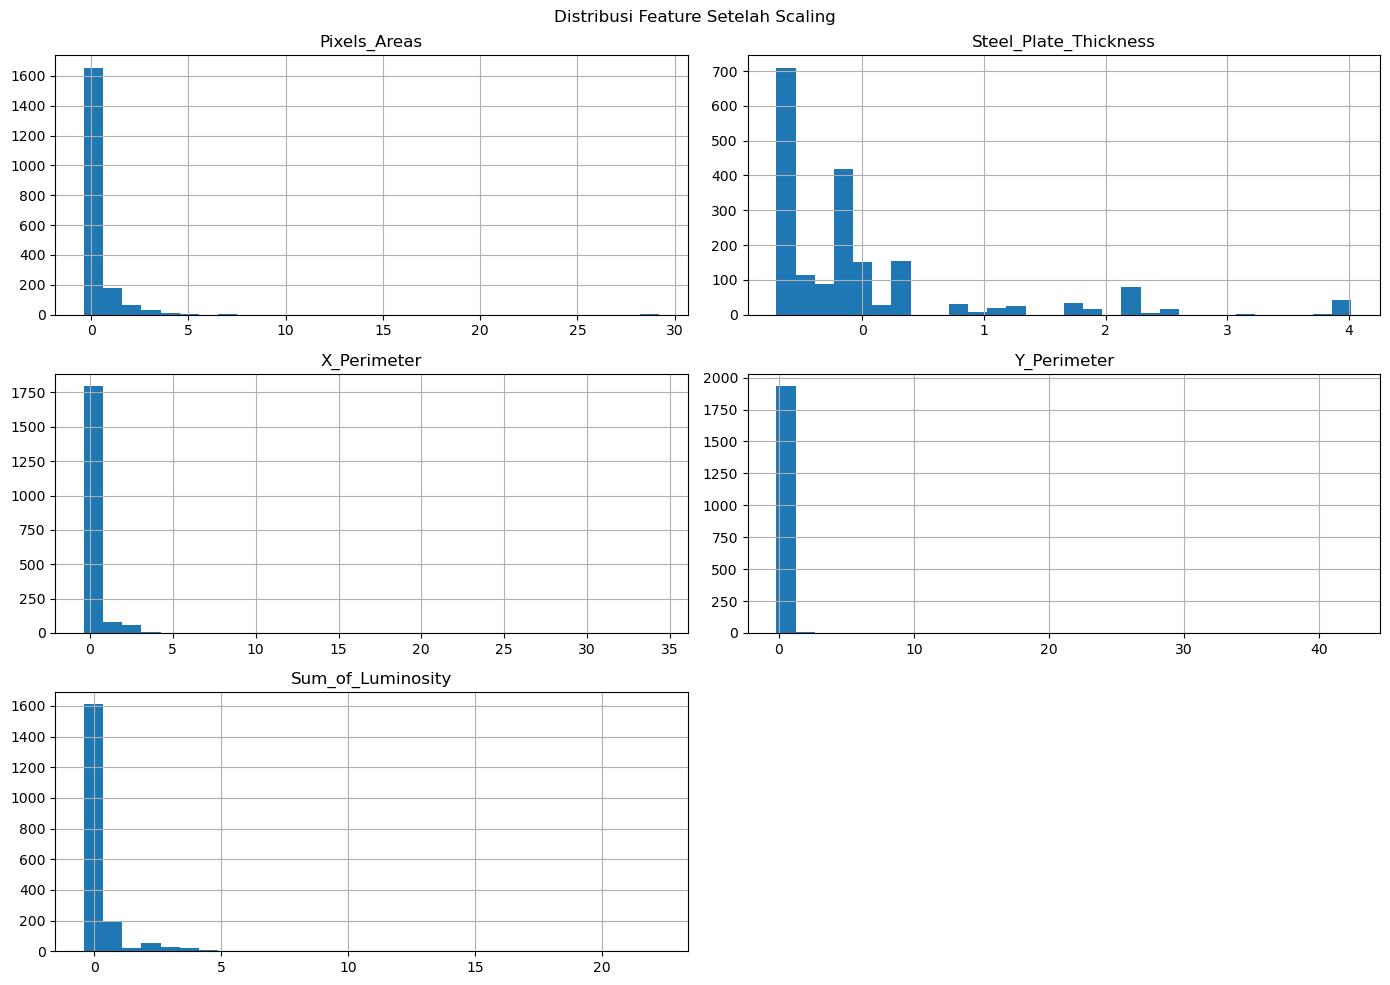

In [7]:
scaled_df = pd.DataFrame(
    X_scaled,
    columns=feature_cols
)

selected_features = [
    "Pixels_Areas",
    "Steel_Plate_Thickness",
    "X_Perimeter",
    "Y_Perimeter",
    "Sum_of_Luminosity"
]

scaled_df[selected_features].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Distribusi Feature Setelah Scaling")
plt.tight_layout()
plt.show()

## 8. Menentukan Jumlah Cluster Optimal

Jumlah cluster pada K-Means dianalisis menggunakan dua pendekatan:

1. Elbow Method
2. Silhouette Score

Elbow Method menggunakan nilai inertia untuk melihat perubahan total
within-cluster sum of squares terhadap jumlah cluster.

Silhouette Score digunakan untuk melihat kualitas pemisahan data antar
cluster.

In [8]:
k_values = range(2, 11)

inertias = []
silhouette_scores = []

for k in k_values:

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    inertias.append(model.inertia_)

    silhouette_scores.append(
        silhouette_score(X_scaled, labels)
    )

print("Perhitungan K-Means untuk berbagai nilai K selesai.")

Perhitungan K-Means untuk berbagai nilai K selesai.


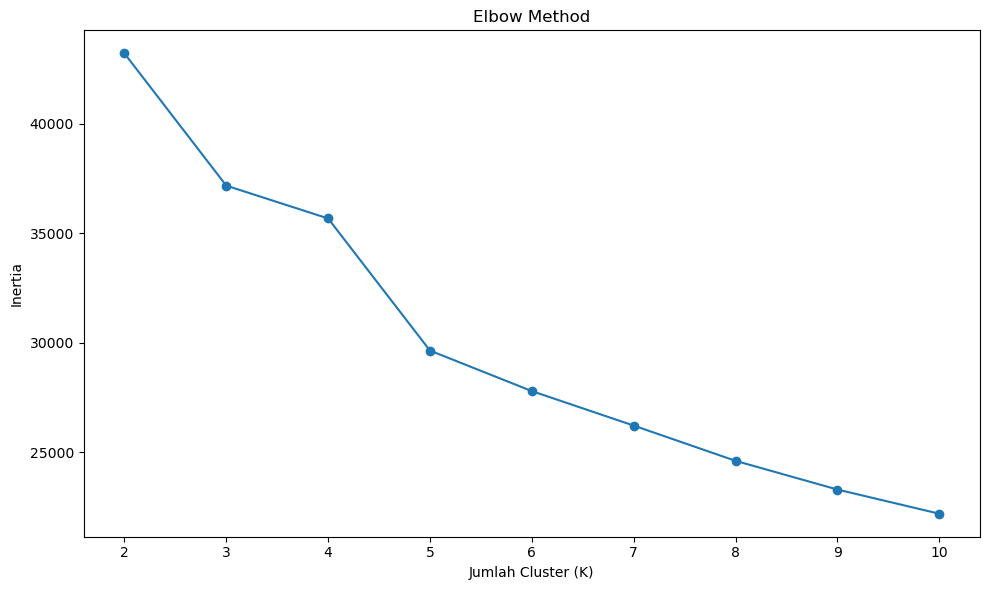

In [9]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    inertias,
    marker="o"
)

plt.title("Elbow Method")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Inertia")

plt.tight_layout()
plt.show()

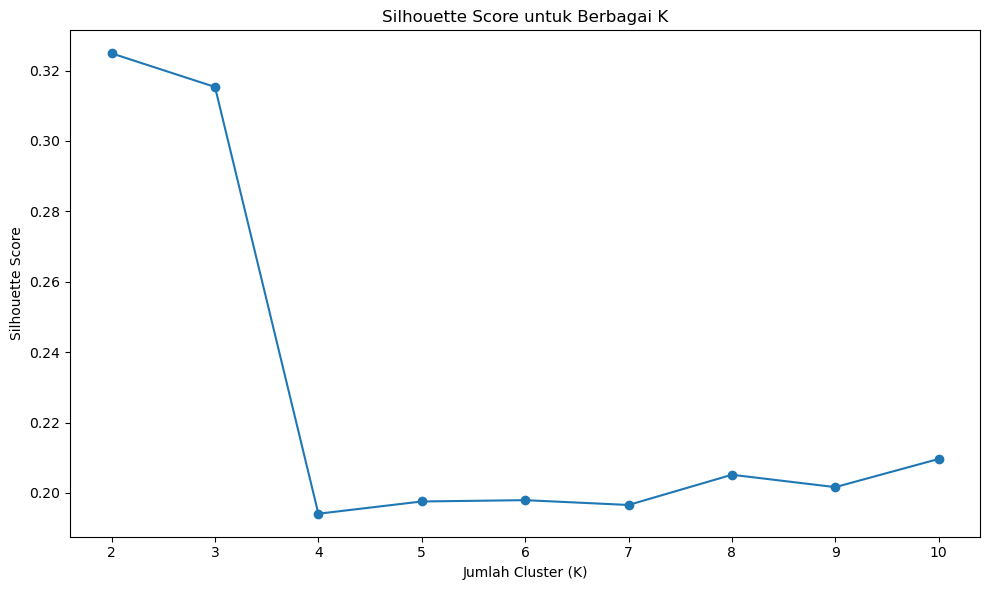

In [10]:
plt.figure(figsize=(10, 6))

plt.plot(
    list(k_values),
    silhouette_scores,
    marker="o"
)

plt.title("Silhouette Score untuk Berbagai K")
plt.xlabel("Jumlah Cluster (K)")
plt.ylabel("Silhouette Score")

plt.tight_layout()
plt.show()

In [11]:
k_results = pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias,
    "Silhouette_Score": silhouette_scores
})

k_results

,K,Inertia,Silhouette_Score
0,2,43219.222452,0.324881
1,3,37177.932119,0.315327
2,4,35679.215698,0.194116
3,5,29644.619027,0.197589
4,6,27794.386884,0.197964
5,7,26219.483651,0.196596
6,8,24609.491091,0.205179
7,9,23298.298358,0.201664
8,10,22194.636950,0.209666


In [12]:
best_k_silhouette = int(
    k_results.loc[
        k_results["Silhouette_Score"].idxmax(),
        "K"
    ]
)

print(
    "K dengan Silhouette Score tertinggi:",
    best_k_silhouette
)

K dengan Silhouette Score tertinggi: 2


## 9. Pemilihan K

Berdasarkan Elbow Method, titik perubahan inertia yang mulai melandai
terlihat pada sekitar K = 2.

Berdasarkan Silhouette Score, nilai tertinggi diperoleh pada K = 2.

K yang digunakan untuk eksperimen utama dipilih dengan mempertimbangkan
kedua hasil tersebut.

In [13]:
# Setelah melihat Elbow Method dan Silhouette Score,
# tetapkan nilai K yang dipilih di sini.

OPTIMAL_K = best_k_silhouette

print("K yang digunakan:", OPTIMAL_K)

K yang digunakan: 2


## 10. K-Means Clustering

K-Means digunakan untuk membagi data menjadi sejumlah cluster berdasarkan
kedekatan data terhadap centroid.

Model dilatih menggunakan data yang telah melalui StandardScaler.

In [14]:
kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

print("K-Means berhasil dilatih.")
print("Jumlah cluster:", OPTIMAL_K)

K-Means berhasil dilatih.
Jumlah cluster: 2


## 11. Agglomerative Clustering

Agglomerative Clustering digunakan sebagai algoritma hierarchical
clustering untuk membandingkan hasil dengan K-Means.

Metode `ward` digunakan sesuai dengan ketentuan tugas.

In [15]:
agglomerative = AgglomerativeClustering(
    n_clusters=OPTIMAL_K,
    linkage="ward"
)

agglomerative_labels = agglomerative.fit_predict(X_scaled)

print("Agglomerative Clustering berhasil dilatih.")

Agglomerative Clustering berhasil dilatih.


## 12. DBSCAN

DBSCAN merupakan algoritma clustering berbasis kepadatan.

Parameter utama:

- `eps`: radius pencarian tetangga
- `min_samples`: jumlah minimum titik untuk membentuk area padat

Data yang diberi label `-1` dianggap sebagai noise.

In [16]:
dbscan_params = [
    (0.5, 5),
    (0.7, 5),
    (0.9, 5),
    (1.1, 5),
    (1.3, 5),
    (0.7, 10),
    (0.9, 10),
    (1.1, 10)
]

dbscan_results = []

for eps, min_samples in dbscan_params:

    model = DBSCAN(
        eps=eps,
        min_samples=min_samples
    )

    labels = model.fit_predict(X_scaled)

    n_clusters = len(
        set(labels) - {-1}
    )

    noise_pct = (
        np.sum(labels == -1)
        / len(labels)
        * 100
    )

    non_noise = labels != -1

    if (
        n_clusters >= 2
        and np.sum(non_noise) > 1
        and len(set(labels[non_noise])) >= 2
    ):

        sil = silhouette_score(
            X_scaled[non_noise],
            labels[non_noise]
        )

        db = davies_bouldin_score(
            X_scaled[non_noise],
            labels[non_noise]
        )

        ch = calinski_harabasz_score(
            X_scaled[non_noise],
            labels[non_noise]
        )

    else:
        sil = np.nan
        db = np.nan
        ch = np.nan

    dbscan_results.append({
        "eps": eps,
        "min_samples": min_samples,
        "Jumlah Cluster": n_clusters,
        "Silhouette Score": sil,
        "Davies-Bouldin": db,
        "Calinski-Harabasz": ch,
        "Noise (%)": noise_pct
    })

dbscan_results = pd.DataFrame(
    dbscan_results
)

dbscan_results

,eps,min_samples,Jumlah Cluster,Silhouette Score,Davies-Bouldin,Calinski-Harabasz,Noise (%)
0,0.5,5,7,0.465878,0.702116,502.564255,90.159711
1,0.7,5,10,0.353935,0.698198,313.887289,85.986605
2,0.9,5,12,0.489308,0.472028,350.642642,83.049974
3,1.1,5,20,0.490563,0.597918,354.376880,79.185987
4,1.3,5,38,0.481528,0.785681,280.998908,68.109222
5,0.7,10,5,0.533487,0.582378,656.595158,89.180835
6,0.9,10,7,0.487550,0.520470,446.436835,85.368367
7,1.1,10,7,0.473867,0.568862,471.403314,84.286450


In [17]:
valid_dbscan = dbscan_results.dropna(
    subset=["Silhouette Score"]
)

best_dbscan = valid_dbscan.loc[
    valid_dbscan["Silhouette Score"].idxmax()
]

BEST_EPS = float(best_dbscan["eps"])
BEST_MIN_SAMPLES = int(
    best_dbscan["min_samples"]
)

print("Parameter DBSCAN:")
print("eps:", BEST_EPS)
print("min_samples:", BEST_MIN_SAMPLES)

Parameter DBSCAN:
eps: 0.7
min_samples: 10


In [18]:
dbscan = DBSCAN(
    eps=BEST_EPS,
    min_samples=BEST_MIN_SAMPLES
)

dbscan_labels = dbscan.fit_predict(X_scaled)

n_dbscan_clusters = len(
    set(dbscan_labels) - {-1}
)

dbscan_noise_pct = (
    np.mean(dbscan_labels == -1)
    * 100
)

print("DBSCAN berhasil dilatih.")
print("Jumlah cluster:", n_dbscan_clusters)
print("Noise:", round(dbscan_noise_pct, 2), "%")

DBSCAN berhasil dilatih.
Jumlah cluster: 5
Noise: 89.18 %


## 13. Evaluasi Clustering

Ketiga algoritma dibandingkan menggunakan metrik internal clustering:

- Silhouette Score
- Davies-Bouldin Index
- Calinski-Harabasz Index
- Jumlah cluster
- Noise percentage

Untuk DBSCAN, titik dengan label `-1` diperlakukan sebagai noise.

In [19]:
def evaluate_clustering(
    X_data,
    labels,
    ignore_noise=False
):
    labels = np.asarray(labels)

    if ignore_noise:
        mask = labels != -1
        X_eval = X_data[mask]
        labels_eval = labels[mask]
    else:
        X_eval = X_data
        labels_eval = labels

    unique_labels = set(labels_eval)

    if len(unique_labels) < 2:
        return {
            "Jumlah Cluster": len(unique_labels),
            "Silhouette Score": np.nan,
            "Davies-Bouldin": np.nan,
            "Calinski-Harabasz": np.nan,
            "Noise (%)": np.mean(labels == -1) * 100
        }

    return {
        "Jumlah Cluster": len(unique_labels),
        "Silhouette Score": silhouette_score(
            X_eval,
            labels_eval
        ),
        "Davies-Bouldin": davies_bouldin_score(
            X_eval,
            labels_eval
        ),
        "Calinski-Harabasz": calinski_harabasz_score(
            X_eval,
            labels_eval
        ),
        "Noise (%)": (
            np.mean(labels == -1) * 100
        )
    }

In [20]:
kmeans_eval = evaluate_clustering(
    X_scaled,
    kmeans_labels
)

agglomerative_eval = evaluate_clustering(
    X_scaled,
    agglomerative_labels
)

dbscan_eval = evaluate_clustering(
    X_scaled,
    dbscan_labels,
    ignore_noise=True
)

comparison = pd.DataFrame(
    [
        kmeans_eval,
        agglomerative_eval,
        dbscan_eval
    ],
    index=[
        "K-Means",
        "Agglomerative",
        "DBSCAN"
    ]
)

comparison

,Jumlah Cluster,Silhouette Score,Davies-Bouldin,Calinski-Harabasz,Noise (%)
K-Means,2,0.324881,1.215826,586.366372,0.000000
Agglomerative,2,0.330563,1.150216,568.594292,0.000000
DBSCAN,5,0.533487,0.582378,656.595158,89.180835


## 14. Distribusi Anggota Cluster

Jumlah data pada setiap cluster diperiksa untuk mengetahui apakah hasil
clustering menghasilkan cluster yang sangat kecil atau tidak proporsional.

In [21]:
cluster_counts = pd.DataFrame({
    "K-Means": pd.Series(
        kmeans_labels
    ).value_counts().sort_index(),

    "Agglomerative": pd.Series(
        agglomerative_labels
    ).value_counts().sort_index(),

    "DBSCAN": pd.Series(
        dbscan_labels
    ).value_counts().sort_index()
})

cluster_counts

,K-Means,Agglomerative,DBSCAN
-1,NaN,NaN,1731
0,1566.0,333.0,11
1,375.0,1608.0,42
2,NaN,NaN,102
3,NaN,NaN,45
4,NaN,NaN,10
